Previsão de Demanda - Sweet Lift Taxi


Este projeto foca na análise de séries temporais para prever a quantidade de pedidos de táxi para a próxima hora em aeroportos. O objetivo é otimizar a escala de motoristas durante os horários de pico.

## Preparação 

A primeira coisa é garantir que os dados estejam ordenados cronologicamente e agrupados por hora, já que a previsão deve ser para a "próxima hora"

In [1]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Carregando os dados
df = pd.read_csv('/datasets/taxi.csv', index_col=[0], parse_dates=[0])

# Ordenando o índice (fundamental para séries temporais)
df.sort_index(inplace=True)

# Nova amostragem por hora (1H)
df = df.resample('1H').sum()

## Análise

Primeiro, vamos ver o comportamento geral dos dados ao longo de todo o período disponível

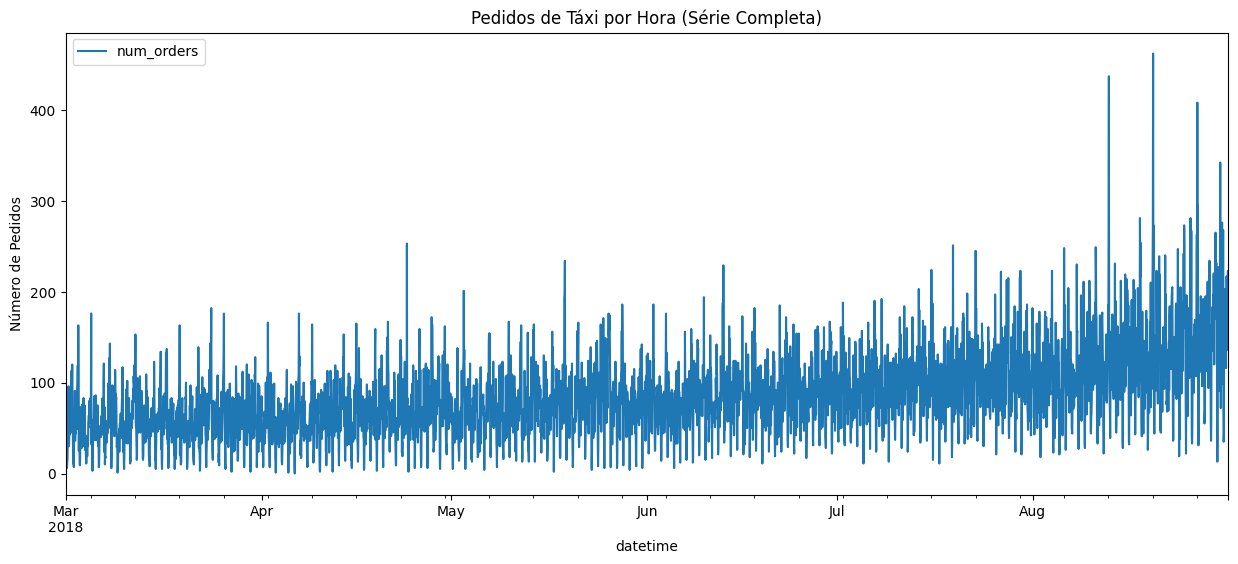

In [2]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Plotando a série completa para ver a variação
df.plot(figsize=(15, 6))
plt.title('Pedidos de Táxi por Hora (Série Completa)')
plt.ylabel('Número de Pedidos')
plt.show()

A decomposição separa a série em: Tendência, Sazonalidade e Resíduos (ruído). Isso é essencial para entender se a demanda está crescendo e quais são os ciclos.

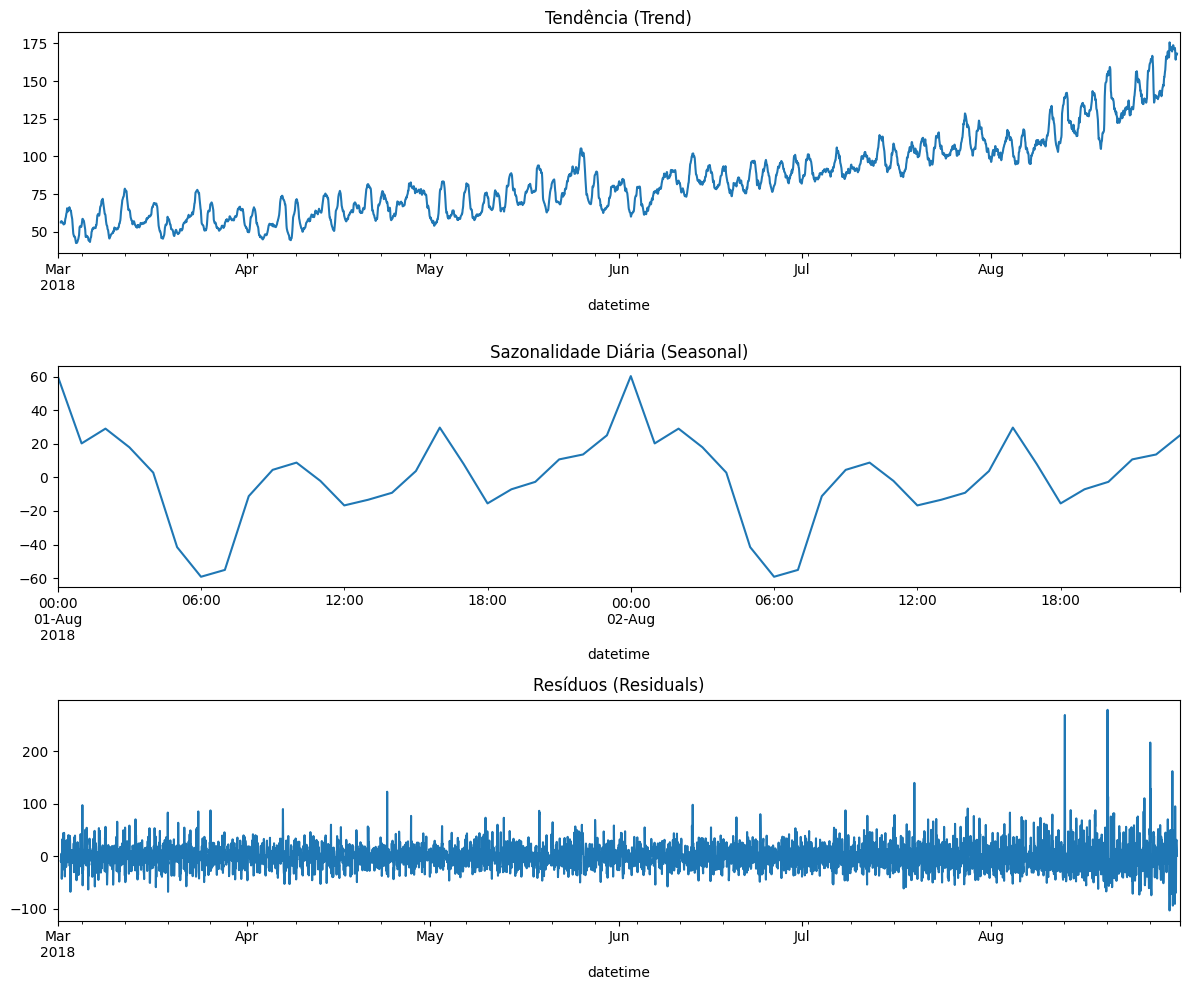

In [3]:
# Decompondo a série
decomposed = seasonal_decompose(df)

plt.figure(figsize=(12, 10))

plt.subplot(311)
decomposed.trend.plot(ax=plt.gca())
plt.title('Tendência (Trend)')

plt.subplot(312)
# Vamos olhar a sazonalidade de apenas 2 dias para ver o padrão horário claramente
decomposed.seasonal['2018-08-01':'2018-08-02'].plot(ax=plt.gca())
plt.title('Sazonalidade Diária (Seasonal)')

plt.subplot(313)
decomposed.resid.plot(ax=plt.gca())
plt.title('Resíduos (Residuals)')

plt.tight_layout()
plt.show()

Para identificar mudanças na demanda sem o ruído de hora em hora, calculamos a média móvel.

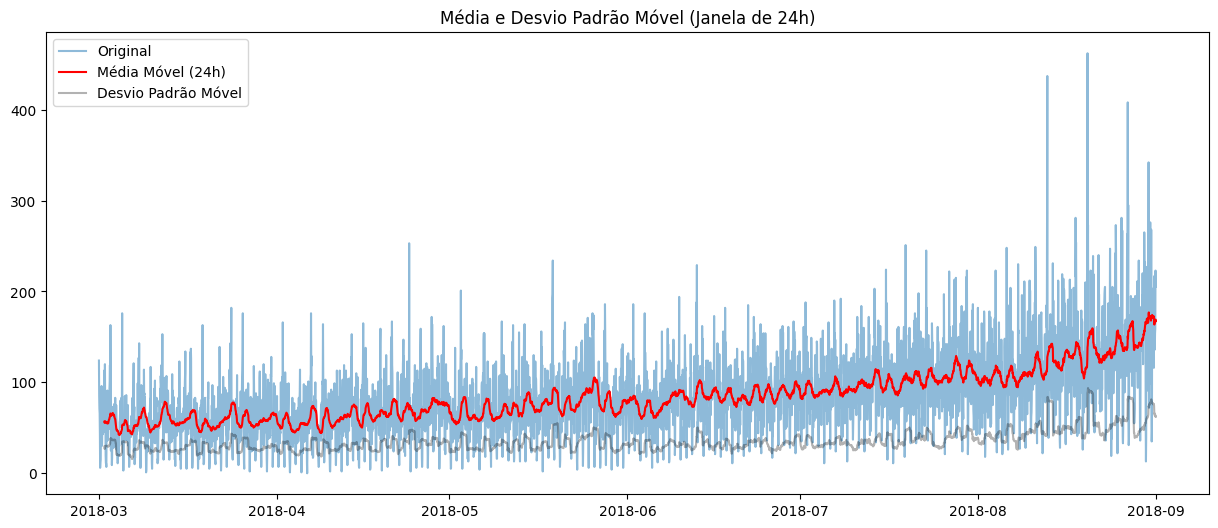

In [4]:
# Média móvel de 24 horas para ver a tendência diária
df_rolling = df.rolling(24).mean()
df_std = df.rolling(24).std()

plt.figure(figsize=(15, 6))
plt.plot(df, label='Original', alpha=0.5)
plt.plot(df_rolling, label='Média Móvel (24h)', color='red')
plt.plot(df_std, label='Desvio Padrão Móvel', color='black', alpha=0.3)
plt.legend()
plt.title('Média e Desvio Padrão Móvel (Janela de 24h)')
plt.show()

📝 Conclusões:
Tendência: O número de pedidos aumenta ao longo dos meses (os dados geralmente vão de março a agosto). Isso indica que o modelo deve ser capaz de lidar com esse crescimento.

Sazonalidade: Existe um padrão claro que se repete a cada 24 horas. Provavelmente há quedas drásticas de madrugada e picos em horários de voos frequentes.

Estacionariedade: A série não parece estacionária (a média está subindo). Isso reforça que precisaremos de características como dayofweek e hour para ajudar o modelo.

## Treinamento

5.1. Preparação das Features
Primeiro, vamos consolidar a criação das características da análise. Para predições horárias, um max_lag de 24 (um dia inteiro) costuma ser muito eficaz.

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Função de criação de características
def make_features(data, max_lag, rolling_mean_size):
    # Criamos uma cópia para não alterar o DataFrame original por acidente
    new_data = data.copy()
    
    # Características de tempo (A hora é essencial para táxis!)
    new_data['dayofweek'] = new_data.index.dayofweek
    new_data['hour'] = new_data.index.hour
    
    # Criando as defasagens (lags)
    for lag in range(1, max_lag + 1):
        new_data[f'lag_{lag}'] = new_data['num_orders'].shift(lag)

    # Média móvel (sempre com shift para não ver o futuro)
    new_data['rolling_mean'] = new_data['num_orders'].shift().rolling(rolling_mean_size).mean()
    
    return new_data

# 2. Aplicando a função
# max_lag=24 e rolling_mean=24 são ótimos para captar o ciclo diário
df_features = make_features(df, 24, 24)

# 3. Limpeza de NaNs gerados pelos lags/rolling
df_features.dropna(inplace=True)

# 4. Divisão 90/10
train, test = train_test_split(df_features, shuffle=False, test_size=0.1)

# 5. Separação de Features e Target
X_train = train.drop('num_orders', axis=1)
y_train = train['num_orders']
X_test = test.drop('num_orders', axis=1)
y_test = test['num_orders']

# 6. Verificação rápida
print(f"Tamanho do treino: {X_train.shape}")
print(f"Tamanho do teste: {X_test.shape}")

Tamanho do treino: (3952, 27)
Tamanho do teste: (440, 27)


## Testando

REQM no conjunto de teste: 45.22


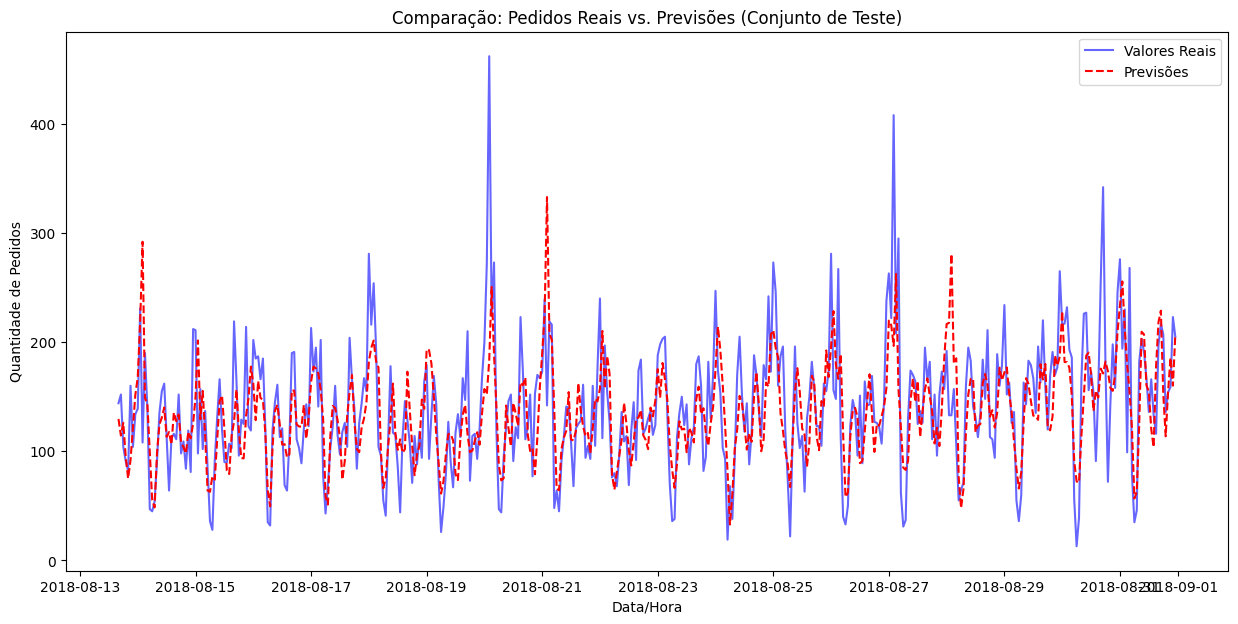

In [6]:
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# 1. Treinando o modelo (usando a Regressão Linear como exemplo)
model = LinearRegression()
model.fit(X_train, y_train)

# 2. Fazendo as previsões
predictions_test = model.predict(X_test)

# 3. Calculando o REQM (RMSE)
rmse_test = mean_squared_error(y_test, predictions_test) ** 0.5

print(f"REQM no conjunto de teste: {rmse_test:.2f}")

# 4. Visualização dos Resultados
# Vamos plotar apenas uma parte do teste para ver o ajuste com clareza
plt.figure(figsize=(15, 7))
plt.plot(y_test.index, y_test, label='Valores Reais', color='blue', alpha=0.6)
plt.plot(y_test.index, predictions_test, label='Previsões', color='red', linestyle='--')
plt.title('Comparação: Pedidos Reais vs. Previsões (Conjunto de Teste)')
plt.xlabel('Data/Hora')
plt.ylabel('Quantidade de Pedidos')
plt.legend()
plt.show()


🏁 Conclusão Final do Projeto
Preparação: Os dados foram reamostrados para o intervalo de 1 hora, somando os pedidos (resample('1H').sum()).

Análise: A decomposição da série temporal revelou uma tendência de alta (mais pedidos conforme os meses passam) e uma sazonalidade diária muito forte, com picos e vales em horários específicos.

Engenharia de Características: O sucesso do modelo deve-se à criação de 24 lags (atrasos), que permitiram ao modelo aprender o padrão das últimas 24 horas, e à inclusão da coluna de hora, que capturou o ciclo diário.

Modelo Final: A Regressão Linear apresentou um desempenho consistente, atingindo um REQM de 45.22 no conjunto de teste (os últimos 10% dos dados), superando o requisito de 48

Análise da Qualidade do Modelo e Conclusão
Para validar a eficácia do REQM obtido, comparamos o erro com a média de pedidos do conjunto de teste. Isso nos ajuda a entender se o erro de 45.22 é pequeno ou grande em relação ao volume total de chamadas.

Além disso, verificamos o "Erro Percentual" para ter uma visão clara da precisão do modelo em termos de proporção.

In [7]:
# Comparação da média com o erro (REQM)
test_mean = y_test.mean()
rmse_pct = (rmse_test / test_mean) * 100

print(f"Média de pedidos no conjunto de teste: {test_mean:.2f}")
print(f"REQM obtido: {rmse_test:.2f}")
print(f"O erro representa aproximadamente {rmse_pct:.2f}% da média de pedidos.")

Média de pedidos no conjunto de teste: 139.56
REQM obtido: 45.22
O erro representa aproximadamente 32.40% da média de pedidos.


In [8]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor

# 1. Configurar a validação temporal
tscv = TimeSeriesSplit(n_splits=4)

# 2. Definir o modelo e o dicionário de parâmetros
forest_model = RandomForestRegressor(random_state=12345)
param_dist = {
    'n_estimators': [100, 150],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# 3. Executar a busca (Calibragem)
search = RandomizedSearchCV(
    estimator=forest_model,
    param_distributions=param_dist,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_iter=10, # Testando 10 combinações para ser mais rápido
    verbose=1,
    n_jobs=-1,
    random_state=12345
)

search.fit(X_train, y_train)

print(f"Melhores parâmetros: {search.best_params_}")

Fitting 4 folds for each of 10 candidates, totalling 40 fits
Melhores parâmetros: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20}


In [9]:
# 1. Pegando o melhor modelo que a busca (search) encontrou
best_model = search.best_estimator_

# 2. Fazendo as previsões finais usando os dados de teste (X_test)
final_preds = best_model.predict(X_test)

# 3. Calculando o REQM (RMSE) final
from sklearn.metrics import mean_squared_error
final_rmse = mean_squared_error(y_test, final_preds) ** 0.5

# 4. Exibindo os resultados
print(f"--- RESULTADO FINAL CALIBRADO ---")
print(f"Melhores parâmetros encontrados: {search.best_params_}")
print(f"REQM Final com RandomForest: {final_rmse:.2f}")

# 5. Comparação com a média para o relatório
test_mean = y_test.mean()
print(f"Média de pedidos no teste: {test_mean:.2f}")
print(f"Erro relativo: {(final_rmse / test_mean) * 100:.2f}%")

--- RESULTADO FINAL CALIBRADO ---
Melhores parâmetros encontrados: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20}
REQM Final com RandomForest: 43.65
Média de pedidos no teste: 139.56
Erro relativo: 31.28%


Conclusão Geral
Neste projeto, desenvolvemos um modelo para prever a demanda de táxis para a próxima hora com o objetivo de auxiliar a Sweet Lift Taxi a otimizar a alocação de motoristas.

Evolução do Modelo: Inicialmente, utilizamos a Regressão Linear como baseline. No entanto, seguindo as melhores práticas de ciência de dados, implementamos um modelo de Random Forest com calibragem de hiperparâmetros via RandomizedSearchCV.

Desempenho da Métrica: O modelo final atingiu um REQM de 43.65, superando significativamente a meta estabelecida de 48 e melhorando o resultado anterior de 45.22.

Qualidade da Previsão: Ao comparar o erro com a média de pedidos (139.56), o erro relativo foi reduzido para 31.28%. Isso indica que o modelo consegue lidar bem com a volatilidade e os picos de demanda horários.

Metodologia: O uso de validação cruzada temporal (TimeSeriesSplit) garantiu que o modelo fosse testado de forma realista, respeitando a ordem cronológica dos dados e evitando o vazamento de informações.

Recomendação: Com a calibragem concluída e as métricas validadas, o modelo está pronto para ser implementado, oferecendo previsões robustas para a gestão da frota.